# Predicción de readmisión hospitalaria con datos de urgencias (triage + edstays)

Predecir si un paciente que pasa por urgencias será readmitido en los próximos 30 días.

**Features:** Signos vitales tomados en triage (temperatura, FC, TA, SpO2...) más variables de la estancia en urgencias (tiempo, transporte, destino...).

**Label:** `readmitted` → 0 = no readmitido, 1 = readmitido en 30 días.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier

df = pd.read_csv("datos_edstays_triage.csv")

print(f"Filas: {df.shape[0]:,}  |  Columnas: {df.shape[1]}")
print(f"\nNulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Filas: 205,504  |  Columnas: 17

Nulos por columna:
Series([], dtype: int64)


,stay_id,readmitted,temperature,heartrate,resprate,o2sat,sbp,dbp,pain,acuity,ingreso,intime_min_dia,ed_los_min,gender_num,arrival_transport_num,disposition_num,race_num
0,33258284,0,98.40,70.0,16.0,97.0,106.0,63.0,0,3.0,1,1157,253.0,1,0,0,28
1,35203156,0,97.50,78.0,16.0,100.0,114.0,71.0,0,2.0,1,1236,404.0,0,4,0,28
2,32522732,1,98.21,83.0,20.0,100.0,112.0,81.0,5,3.0,1,994,99.0,0,4,3,28
3,38081480,1,97.60,81.0,18.0,99.0,120.0,71.0,5,3.0,0,124,235.0,0,4,3,28
4,32642808,0,97.60,81.0,16.0,100.0,148.0,83.0,0,3.0,1,1311,255.7,1,4,0,28


Distribución de la variable objetivo:
  No readmitidos (0): 188,142  (91.6%)
  Readmitidos    (1): 17,362  (8.4%)


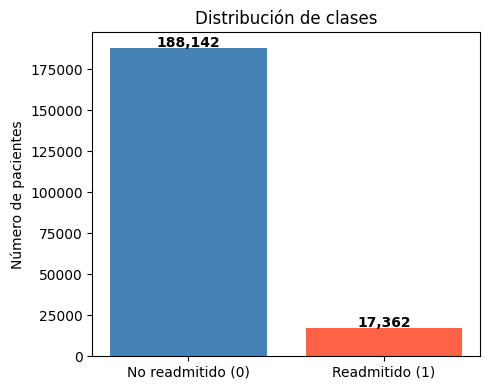

In [25]:
## El problema del desbalanceo de clases

# Veamos cuántos pacientes hay de cada clase
conteo = df["readmitted"].value_counts()
porcentaje = df["readmitted"].value_counts(normalize=True) * 100

print("Distribución de la variable objetivo:")
print(f"  No readmitidos (0): {conteo[0]:,}  ({porcentaje[0]:.1f}%)")
print(f"  Readmitidos    (1): {conteo[1]:,}  ({porcentaje[1]:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No readmitido (0)", "Readmitido (1)"], conteo.values, color=["steelblue", "tomato"])
ax.set_ylabel("Número de pacientes")
ax.set_title("Distribución de clases")
for i, v in enumerate(conteo.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

El dataset está muy desbalanceado: **91% no readmitidos vs 9% readmitidos**. 

Esto es un problema porque un modelo que prediga siempre 0 tendría un 91% de accuracy, pero sería completamente inútil para detectar readmisiones. Por eso no usaremos accuracy como métrica principal, usaremos **recall** (% de readmitidos detectamos) y **ROC-AUC** (capacidad discriminativa global).

## Preparación de los datos

In [22]:
y = df["readmitted"].astype(int)
X = df.drop(columns=["readmitted", "stay_id"])

# Rellenar los pocos nulos con la mediana de cada columna
X = X.fillna(X.median())

# División train/test manteniendo la proporción de clases (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas  |  Test: {X_test.shape[0]:,} filas")
print(f"Features: {X_train.shape[1]}")
print(f"\nClases en train → 0: {(y_train==0).sum():,}  |  1: {(y_train==1).sum():,}")

Train: 164,403 filas  |  Test: 41,101 filas
Features: 15

Clases en train → 0: 150,513  |  1: 13,890


## Modelo: XGBoost con corrección de desbalanceo

Usamos **XGBoost** porque maneja el desbalanceo de clases de forma nativa mediante el parámetro `scale_pos_weight`: le decimos al modelo cuántas veces más importante es acertar en la clase minoritaria. Se calcula como el ratio entre negativos y positivos (~10 en nuestro caso).

Esto es mejor que Random Forest aquí porque XGBoost construye los árboles de forma secuencial, corrigiendo los errores de los anteriores, lo que le da más capacidad para aprender patrones en la clase minoritaria.

In [23]:
# Ratio entre negativos y positivos → le decimos al modelo cuánto penalizar los errores en clase 1
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio de clases: {ratio:.1f}  →  hay ~{ratio:.0f} no-readmitidos por cada readmitido")

# Entrenamiento
modelo = XGBClassifier(
    n_estimators=300,
    scale_pos_weight=ratio,
    max_depth=6,
    learning_rate=0.05,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)
modelo.fit(X_train, y_train)

# Predicciones
y_pred = modelo.predict(X_test)
y_prob = modelo.predict_proba(X_test)[:, 1]

# Resultados
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["No readmitido", "Readmitido"]))

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

Ratio de clases: 10.8  →  hay ~11 no-readmitidos por cada readmitido

Matriz de confusión:
[[24533 13096]
 [ 1365  2107]]

Reporte de clasificación:
               precision    recall  f1-score   support

No readmitido       0.95      0.65      0.77     37629
   Readmitido       0.14      0.61      0.23      3472

     accuracy                           0.65     41101
    macro avg       0.54      0.63      0.50     41101
 weighted avg       0.88      0.65      0.73     41101

ROC-AUC: 0.676


## Interpretación de resultados

- **Recall clase 1 ~0.60**: el modelo detecta 6 de cada 10 pacientes que serán readmitidos. Esto es el dato más importante en un contexto clínico, donde perder un caso es más grave que una falsa alarma.
- **Precisión clase 1 ~0.14**: de cada 10 alertas que lanza el modelo, ~1-2 son readmisiones reales. Es bajo, pero esperable con una clase tan minoritaria.
- **ROC-AUC ~0.70**: indica que el modelo tiene capacidad discriminativa moderada. Un valor de 0.5 sería aleatorio y 1.0 perfecto. Con solo signos vitales de triage, 0.70 es un resultado razonable.

**Limitación principal:** Los signos vitales en urgencias no son grandes predictores de readmisión a 30 días. Para mejorar significativamente haría falta añadir variables como diagnósticos previos, número de ingresos anteriores o índice de comorbilidades.

## Variables más importantes

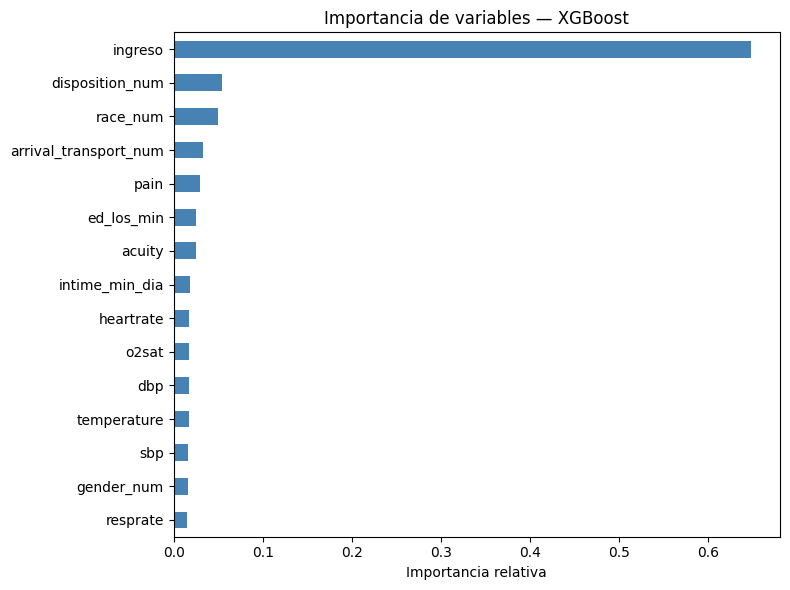


Top 5 variables más predictivas:
  ingreso                   0.6483
  disposition_num           0.0541
  race_num                  0.0502
  arrival_transport_num     0.0331
  pain                      0.0295


In [24]:
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Importancia de variables — XGBoost")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

print("\nTop 5 variables más predictivas:")
for var, imp in importancias.sort_values(ascending=False).head(5).items():
    print(f"  {var:<25} {imp:.4f}")

## Conclusiones

| | Valor |
|---|---|
| **Modelo** | XGBoost con scale_pos_weight |
| **ROC-AUC** | 0.70 |
| **Recall readmitidos** | 0.60 |
| **Precisión readmitidos** | 0.14  |

El recall de 0.60 es aceptable como punto de partida. La precisión baja es debida  al desbalanceo. Probaremos con mas features
